In [1]:
# Assignment 1
# Name: Kareem Ayman Ghabayen
# ID: 1301214508  

In [2]:
# the libarys 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# i uploaded the file and this code reads the file called (df)
df = pd.read_csv('titanic.csv')

print(f"Dataset Shape: {df.shape}") 
df.head()

Dataset Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
#1. Detecting and Handling Missing Values like the empty rows deck and empty ages  

df['age'] = df['age'].fillna(df['age'].median())

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
# added errors ignored because if we run the code twice the second time it wont work because already deleted so it will ignore it . 
df.drop(columns=['deck'], inplace=True, errors='ignore')
print("task 1>>>>> Missing values Detected!")
df.isnull().sum()

task 1>>>>> Missing values Detected!


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [4]:
#2. Detecting and Handling Duplicate Values 

print(f"Total duplicates found: {df.duplicated().sum()}")

#this code deletes the duplicates 
df.drop_duplicates(inplace=True)

print(" task 2 >>>>> Duplicates removed!!!")

Total duplicates found: 116
 task 2 >>>>> Duplicates removed!!!


In [5]:
# 3. Detecting and Handling Outliers#

# Calculate the quartiles (Q1 and Q3) to find the IQR
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Replace any price higher than the limit with the limit value
df['fare'] = np.where(df['fare'] > upper_bound, upper_bound, df['fare'])

print("task 3>>>>>> Outliers in 'fare' handled!")

task 3>>>>>> Outliers in 'fare' handled!


Survival rates (1.0 = 100%):
sex
female    0.739726
male      0.215321
Name: survived, dtype: float64


C:\Users\test\AppData\Local\Temp\ipykernel_18556\2254876228.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, palette='magma')


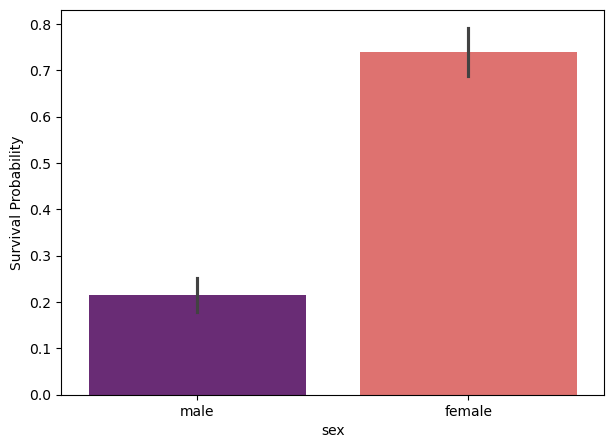

In [6]:
 #  3. Analyze survival rates based on gender and visualize them.
##  Calculate the average survival for each gender male ot female 
survival_stats = df.groupby('sex')['survived'].mean()
print("Survival rates (1.0 = 100%):")
print(survival_stats)

plt.figure(figsize=(7, 5))
sns.barplot(x='sex', y='survived', data=df, palette='magma')
plt.ylabel('Survival Probability')
plt.show()

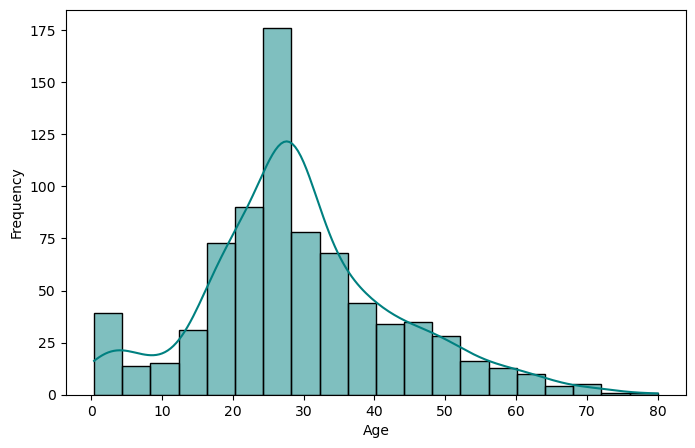

In [7]:
#  4. Create a histogram of passenger ages.
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [8]:
# Summary
# In this assignment i cleaned and analyzed a real dataset using Python , supmited explaination for some codes i wrote above and my work included:

#1 Data Cleaning: I  detect and remove duplicate records to make the data accurate. I also removed useless columns and filled in missing info.

#2 Calculations: I  calculated the average (mean) for different groups, like the survival rate for males and the females.

# 3 Data Visualization: I have made  the data visual by creating bar plots and histograms. it helps to understand the numbers easily.

# 4 The analysis showed that women had a much higher survival rate than men, and most passengers were young adults.